# Deep Learning Model Implementation Using PyTorch & Brainwave Data
- Saint Cloud State University (SCSU), Avatar Open Source Project Issue #299
- Created by: Giovanni Antunez

## Objectives

- Create a deep learning model using PyTorch and Brainwave data that could be used to identify drone commands. 
<br>
- Compare performance/results between this new PyTorch model and the existing TensorFlow implementation
<br>
- Create a pull request to add PyTorch implementation and trained model to the directory Avatar/deep-learning-prediction/pytorch.
<br>
<br>

## Packages/Libraries

In [73]:
# Use for data processing
import pathlib
import pandas as pd
import numpy as np
import sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Use for model evaluation
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Use for PyTorch model implementation
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchsummary
from torchsummary import summary
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Use for data visualizations
import matplotlib.pyplot as plt
import seaborn as sns



## Data Preparation

### Get Files

In [74]:
## Load Brainwave data - electroencephalography (EEG) signals 

# get directory
directory_path = "/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/" # Replace with your desired path

core_dir = pathlib.Path(directory_path)
skip_dirs = ["Group1-8channels"] 

# get data
dfs = []

for item in core_dir.rglob('*.txt'):
    try:
        if set(item.parts).isdisjoint(skip_dirs):
            df = pd.read_csv(item, sep=',', header=4, on_bad_lines='skip')
            df["src_filename"] = str(item)
            dfs.append(df)
            print(f"Read {item}")
    except Exception as e:
        print(f"Failed to read {item}: {e}")



Read /home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-58-31.txt
Read /home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_13-00-06.txt
Read /home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-57-41.txt
Read /home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-59-22.txt
Read /home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-58-15.txt
Read /home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-57-58.txt
Read /home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-59-05.txt
Read /home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-

In [75]:
dfs[:10]

[      Sample Index   EXG Channel 0   EXG Channel 1   EXG Channel 2  \
 0            222.0   -51868.765279   -42330.225388   -62246.747285   
 1            224.0   -51879.091785   -42335.500400   -62249.161273   
 2            226.0   -51862.998529   -42324.659803   -62239.348857   
 3            228.0   -51866.440697   -42327.565530   -62240.757017   
 4            230.0   -51871.671006   -42334.583978   -62246.322602   
 ...            ...             ...             ...             ...   
 1386         196.0   -51858.841104   -42480.317352   -62142.878728   
 1387         198.0   -51859.221084   -42481.770215   -62145.605641   
 1388         200.0   -51875.850782   -42496.567070   -62159.061391   
 1389         202.0   -51845.318299   -42470.214363   -62129.735903   
 1390         204.0   -51852.873189   -42474.640009   -62136.061446   
 
        EXG Channel 3   EXG Channel 4   EXG Channel 5   EXG Channel 6  \
 0      -63465.565558   -61098.985207   -53696.892106   -55024.541023   


### Combine data

In [76]:
# combine        
eeg_data = pd.concat(dfs, ignore_index=True)

/tmp/ipykernel_9704/2650804897.py:2: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  eeg_data = pd.concat(dfs, ignore_index=True)


In [77]:
eeg_data.columns

Index(['Sample Index', ' EXG Channel 0', ' EXG Channel 1', ' EXG Channel 2',
       ' EXG Channel 3', ' EXG Channel 4', ' EXG Channel 5', ' EXG Channel 6',
       ' EXG Channel 7', ' EXG Channel 8', ' EXG Channel 9', ' EXG Channel 10',
       ' EXG Channel 11', ' EXG Channel 12', ' EXG Channel 13',
       ' EXG Channel 14', ' EXG Channel 15', ' Accel Channel 0',
       ' Accel Channel 1', ' Accel Channel 2', ' Not Used',
       ' Digital Channel 0 (D11)', ' Digital Channel 1 (D12)',
       ' Digital Channel 2 (D13)', ' Digital Channel 3 (D17)', ' Not Used.1',
       ' Digital Channel 4 (D18)', ' Analog Channel 0', ' Analog Channel 1',
       ' Analog Channel 2', ' Timestamp', ' Marker Channel',
       ' Timestamp (Formatted)', 'src_filename'],
      dtype='object')

In [78]:
eeg_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2885310 entries, 0 to 2885309
Data columns (total 34 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   Sample Index              float64
 1    EXG Channel 0            float64
 2    EXG Channel 1            float64
 3    EXG Channel 2            float64
 4    EXG Channel 3            float64
 5    EXG Channel 4            float64
 6    EXG Channel 5            float64
 7    EXG Channel 6            float64
 8    EXG Channel 7            float64
 9    EXG Channel 8            float64
 10   EXG Channel 9            float64
 11   EXG Channel 10           float64
 12   EXG Channel 11           float64
 13   EXG Channel 12           float64
 14   EXG Channel 13           float64
 15   EXG Channel 14           float64
 16   EXG Channel 15           float64
 17   Accel Channel 0          float64
 18   Accel Channel 1          float64
 19   Accel Channel 2          float64
 20   Not Used               

In [79]:
eeg_data.head(10)

,Sample Index,EXG Channel 0,EXG Channel 1,EXG Channel 2,EXG Channel 3,EXG Channel 4,EXG Channel 5,EXG Channel 6,EXG Channel 7,EXG Channel 8,...,Digital Channel 3 (D17),Not Used.1,Digital Channel 4 (D18),Analog Channel 0,Analog Channel 1,Analog Channel 2,Timestamp,Marker Channel,Timestamp (Formatted),src_filename
0,222.0,-51868.765279,-42330.225388,-62246.747285,-63465.565558,-61098.985207,-53696.892106,-55024.541023,-46696.169281,-17776.208255,...,0.0,0.0,0.0,0.0,0.0,0.0,1.741802e+09,0.0,2025-03-12 12:58:31.957,/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-58-31.txt
1,224.0,-51879.091785,-42335.500400,-62249.161273,-63470.415887,-61101.510954,-53701.965952,-55026.552680,-46702.539528,-17787.764107,...,0.0,0.0,0.0,0.0,0.0,0.0,1.741802e+09,0.0,2025-03-12 12:58:31.957,/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-58-31.txt
2,226.0,-51862.998529,-42324.659803,-62239.348857,-63461.117561,-61093.173753,-53688.107871,-55016.606154,-46694.269382,-17775.872979,...,0.0,0.0,0.0,0.0,0.0,0.0,1.741802e+09,0.0,2025-03-12 12:58:31.958,/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-58-31.txt
3,228.0,-51866.440697,-42327.565530,-62240.757017,-63461.966927,-61093.509030,-53689.046644,-55021.300020,-46681.506536,-17774.420115,...,0.0,0.0,0.0,0.0,0.0,0.0,1.741802e+09,0.0,2025-03-12 12:58:31.959,/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-58-31.txt
4,230.0,-51871.671006,-42334.583978,-62246.322602,-63466.414924,-61096.750033,-53692.198240,-55022.998753,-46691.140138,-17782.846723,...,104.0,124.0,0.0,0.0,0.0,0.0,1.741802e+09,0.0,2025-03-12 12:58:31.959,/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-58-31.txt
5,232.0,-51876.789555,-42332.505266,-62246.210843,-63466.705497,-61093.486678,-53691.415929,-55025.479797,-46693.151795,-17791.027461,...,0.0,0.0,0.0,0.0,0.0,0.0,1.741802e+09,0.0,2025-03-12 12:58:31.959,/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-58-31.txt
6,234.0,-51835.684697,-42296.630716,-62213.040854,-63433.736674,-61061.747201,-53660.145838,-54994.500279,-46656.249065,-17763.892444,...,0.0,0.0,0.0,0.0,0.0,0.0,1.741802e+09,0.0,2025-03-12 12:58:31.960,/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-58-31.txt
7,236.0,-51847.888750,-42308.365382,-62223.099139,-63443.459683,-61075.337061,-53670.494696,-55006.771386,-46673.079929,-17752.850682,...,0.0,0.0,0.0,0.0,0.0,0.0,1.741802e+09,0.0,2025-03-12 12:58:31.960,/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-58-31.txt
8,0.0,-25886.382268,-21197.500372,-31116.310491,-31729.597655,-30539.277856,-26844.713312,-27526.396814,-23330.393235,-8884.013758,...,80.0,123.0,112.0,0.0,0.0,0.0,1.741802e+09,0.0,2025-03-12 12:58:32.127,/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-58-31.txt
9,2.0,-51781.682883,-42407.294203,-62249.183625,-63474.394497,-61093.240809,-53702.189470,-55068.350442,-46672.655245,-18255.630822,...,0.0,0.0,0.0,0.0,0.0,0.0,1.741802e+09,0.0,2025-03-12 12:58:32.128,/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-58-31.txt


### Get Labels

In [80]:
## Set Labels

# create a final dataset to update
eeg_data_fnl = eeg_data

# update label text
eeg_data_fnl["label_txt"] = ""
label_names = ["backward","forward","landing","left","right","takeoff","fowward"]

for label in label_names:
    eeg_data_fnl["label_txt"] = np.where(
        (eeg_data_fnl["label_txt"] == "") & eeg_data_fnl["src_filename"].str.lower().str.contains(label),
        label,
        eeg_data_fnl["label_txt"] 
    )

# rename fowward to forward
eeg_data_fnl["label_txt"] = np.where(
    eeg_data_fnl["label_txt"] == "fowward", "forward",
    eeg_data_fnl["label_txt"]
    ) #TODO: Is there a better way to handle these files named incorrectly?


In [81]:
# see records by label
print(eeg_data_fnl.groupby(["label_txt"])["Sample Index"].count())

label_txt
            353478
backward    436550
forward     472646
landing     479132
left        473995
right       481853
takeoff     187656
Name: Sample Index, dtype: int64


In [82]:
# validate counts at the file name level as needed
pd.set_option("display.max_colwidth", None)
print(eeg_data_fnl.groupby(["label_txt","src_filename"])["Sample Index"].count())

label_txt  src_filename                                                                                                                
           /home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G01/person01/backard/OpenBCI-RAW-2025-03-03_12-02-10.txt    2588
           /home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G01/person01/backard/OpenBCI-RAW-2025-03-03_12-03-25.txt    2601
           /home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G01/person01/backard/OpenBCI-RAW-2025-03-03_12-04-00.txt    2604
           /home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G01/person01/backard/OpenBCI-RAW-2025-03-03_12-04-31.txt    2636
           /home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G01/person01/backard/OpenBCI-RAW-2025-03-03_12-05-01.txt    2532
                                                                                                                                           ... 


In [83]:
eeg_data_fnl.head(10)

,Sample Index,EXG Channel 0,EXG Channel 1,EXG Channel 2,EXG Channel 3,EXG Channel 4,EXG Channel 5,EXG Channel 6,EXG Channel 7,EXG Channel 8,...,Not Used.1,Digital Channel 4 (D18),Analog Channel 0,Analog Channel 1,Analog Channel 2,Timestamp,Marker Channel,Timestamp (Formatted),src_filename,label_txt
0,222.0,-51868.765279,-42330.225388,-62246.747285,-63465.565558,-61098.985207,-53696.892106,-55024.541023,-46696.169281,-17776.208255,...,0.0,0.0,0.0,0.0,0.0,1.741802e+09,0.0,2025-03-12 12:58:31.957,/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-58-31.txt,left
1,224.0,-51879.091785,-42335.500400,-62249.161273,-63470.415887,-61101.510954,-53701.965952,-55026.552680,-46702.539528,-17787.764107,...,0.0,0.0,0.0,0.0,0.0,1.741802e+09,0.0,2025-03-12 12:58:31.957,/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-58-31.txt,left
2,226.0,-51862.998529,-42324.659803,-62239.348857,-63461.117561,-61093.173753,-53688.107871,-55016.606154,-46694.269382,-17775.872979,...,0.0,0.0,0.0,0.0,0.0,1.741802e+09,0.0,2025-03-12 12:58:31.958,/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-58-31.txt,left
3,228.0,-51866.440697,-42327.565530,-62240.757017,-63461.966927,-61093.509030,-53689.046644,-55021.300020,-46681.506536,-17774.420115,...,0.0,0.0,0.0,0.0,0.0,1.741802e+09,0.0,2025-03-12 12:58:31.959,/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-58-31.txt,left
4,230.0,-51871.671006,-42334.583978,-62246.322602,-63466.414924,-61096.750033,-53692.198240,-55022.998753,-46691.140138,-17782.846723,...,124.0,0.0,0.0,0.0,0.0,1.741802e+09,0.0,2025-03-12 12:58:31.959,/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-58-31.txt,left
5,232.0,-51876.789555,-42332.505266,-62246.210843,-63466.705497,-61093.486678,-53691.415929,-55025.479797,-46693.151795,-17791.027461,...,0.0,0.0,0.0,0.0,0.0,1.741802e+09,0.0,2025-03-12 12:58:31.959,/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-58-31.txt,left
6,234.0,-51835.684697,-42296.630716,-62213.040854,-63433.736674,-61061.747201,-53660.145838,-54994.500279,-46656.249065,-17763.892444,...,0.0,0.0,0.0,0.0,0.0,1.741802e+09,0.0,2025-03-12 12:58:31.960,/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-58-31.txt,left
7,236.0,-51847.888750,-42308.365382,-62223.099139,-63443.459683,-61075.337061,-53670.494696,-55006.771386,-46673.079929,-17752.850682,...,0.0,0.0,0.0,0.0,0.0,1.741802e+09,0.0,2025-03-12 12:58:31.960,/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-58-31.txt,left
8,0.0,-25886.382268,-21197.500372,-31116.310491,-31729.597655,-30539.277856,-26844.713312,-27526.396814,-23330.393235,-8884.013758,...,123.0,112.0,0.0,0.0,0.0,1.741802e+09,0.0,2025-03-12 12:58:32.127,/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-58-31.txt,left
9,2.0,-51781.682883,-42407.294203,-62249.183625,-63474.394497,-61093.240809,-53702.189470,-55068.350442,-46672.655245,-18255.630822,...,0.0,0.0,0.0,0.0,0.0,1.741802e+09,0.0,2025-03-12 12:58:32.128,/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-58-31.txt,left


In [84]:
# encode labels
le = LabelEncoder()
eeg_data_fnl["label"] = le.fit_transform(eeg_data_fnl["label_txt"])

In [85]:
eeg_data_fnl.head(10)

,Sample Index,EXG Channel 0,EXG Channel 1,EXG Channel 2,EXG Channel 3,EXG Channel 4,EXG Channel 5,EXG Channel 6,EXG Channel 7,EXG Channel 8,...,Digital Channel 4 (D18),Analog Channel 0,Analog Channel 1,Analog Channel 2,Timestamp,Marker Channel,Timestamp (Formatted),src_filename,label_txt,label
0,222.0,-51868.765279,-42330.225388,-62246.747285,-63465.565558,-61098.985207,-53696.892106,-55024.541023,-46696.169281,-17776.208255,...,0.0,0.0,0.0,0.0,1.741802e+09,0.0,2025-03-12 12:58:31.957,/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-58-31.txt,left,4
1,224.0,-51879.091785,-42335.500400,-62249.161273,-63470.415887,-61101.510954,-53701.965952,-55026.552680,-46702.539528,-17787.764107,...,0.0,0.0,0.0,0.0,1.741802e+09,0.0,2025-03-12 12:58:31.957,/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-58-31.txt,left,4
2,226.0,-51862.998529,-42324.659803,-62239.348857,-63461.117561,-61093.173753,-53688.107871,-55016.606154,-46694.269382,-17775.872979,...,0.0,0.0,0.0,0.0,1.741802e+09,0.0,2025-03-12 12:58:31.958,/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-58-31.txt,left,4
3,228.0,-51866.440697,-42327.565530,-62240.757017,-63461.966927,-61093.509030,-53689.046644,-55021.300020,-46681.506536,-17774.420115,...,0.0,0.0,0.0,0.0,1.741802e+09,0.0,2025-03-12 12:58:31.959,/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-58-31.txt,left,4
4,230.0,-51871.671006,-42334.583978,-62246.322602,-63466.414924,-61096.750033,-53692.198240,-55022.998753,-46691.140138,-17782.846723,...,0.0,0.0,0.0,0.0,1.741802e+09,0.0,2025-03-12 12:58:31.959,/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-58-31.txt,left,4
5,232.0,-51876.789555,-42332.505266,-62246.210843,-63466.705497,-61093.486678,-53691.415929,-55025.479797,-46693.151795,-17791.027461,...,0.0,0.0,0.0,0.0,1.741802e+09,0.0,2025-03-12 12:58:31.959,/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-58-31.txt,left,4
6,234.0,-51835.684697,-42296.630716,-62213.040854,-63433.736674,-61061.747201,-53660.145838,-54994.500279,-46656.249065,-17763.892444,...,0.0,0.0,0.0,0.0,1.741802e+09,0.0,2025-03-12 12:58:31.960,/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-58-31.txt,left,4
7,236.0,-51847.888750,-42308.365382,-62223.099139,-63443.459683,-61075.337061,-53670.494696,-55006.771386,-46673.079929,-17752.850682,...,0.0,0.0,0.0,0.0,1.741802e+09,0.0,2025-03-12 12:58:31.960,/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-58-31.txt,left,4
8,0.0,-25886.382268,-21197.500372,-31116.310491,-31729.597655,-30539.277856,-26844.713312,-27526.396814,-23330.393235,-8884.013758,...,112.0,0.0,0.0,0.0,1.741802e+09,0.0,2025-03-12 12:58:32.127,/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-58-31.txt,left,4
9,2.0,-51781.682883,-42407.294203,-62249.183625,-63474.394497,-61093.240809,-53702.189470,-55068.350442,-46672.655245,-18255.630822,...,0.0,0.0,0.0,0.0,1.741802e+09,0.0,2025-03-12 12:58:32.128,/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean/G03/person02/Left/OpenBCI-RAW-2025-03-12_12-58-31.txt,left,4


In [86]:
print("Classes:", le.classes_)

Classes: ['' 'backward' 'forward' 'landing' 'left' 'right' 'takeoff']


In [87]:
print(eeg_data_fnl.groupby(["label_txt","label"])["Sample Index"].count())

label_txt  label
           0        353478
backward   1        436550
forward    2        472646
landing    3        479132
left       4        473995
right      5        481853
takeoff    6        187656
Name: Sample Index, dtype: int64


### Create final dataset for train & test splits

In [88]:
#eeg_data_fnl = eeg_data_fnl.sample(n = 10000) # just for testing code

X = eeg_data_fnl.iloc[:, 1:17]
y = pd.DataFrame(eeg_data_fnl.iloc[:, -1])

In [89]:
X[" EXG Channel 0"].count()

np.int64(2885310)

In [90]:
X.head(10)

,EXG Channel 0,EXG Channel 1,EXG Channel 2,EXG Channel 3,EXG Channel 4,EXG Channel 5,EXG Channel 6,EXG Channel 7,EXG Channel 8,EXG Channel 9,EXG Channel 10,EXG Channel 11,EXG Channel 12,EXG Channel 13,EXG Channel 14,EXG Channel 15
0,-51868.765279,-42330.225388,-62246.747285,-63465.565558,-61098.985207,-53696.892106,-55024.541023,-46696.169281,-17776.208255,-46157.246370,-53039.817874,2.442340e+06,-50064.465411,-55563.016899,-45352.404756,-3241.114705
1,-51879.091785,-42335.500400,-62249.161273,-63470.415887,-61101.510954,-53701.965952,-55026.552680,-46702.539528,-17787.764107,-46168.377539,-53050.658470,2.442289e+06,-50073.607275,-55571.890542,-45364.340587,-3250.301272
2,-51862.998529,-42324.659803,-62239.348857,-63461.117561,-61093.173753,-53688.107871,-55016.606154,-46694.269382,-17775.872979,-46157.246370,-53038.297956,2.442170e+06,-50065.940626,-55561.988719,-45349.141401,-3240.980594
3,-51866.440697,-42327.565530,-62240.757017,-63461.966927,-61093.509030,-53689.046644,-55021.300020,-46681.506536,-17774.420115,-46151.814896,-53034.900491,2.442063e+06,-50060.442097,-55554.232663,-45347.532075,-3232.844559
4,-51871.671006,-42334.583978,-62246.322602,-63466.414924,-61096.750033,-53692.198240,-55022.998753,-46691.140138,-17782.846723,-46157.760460,-53039.147322,2.441936e+06,-50068.108746,-55560.468800,-45352.963549,-3241.762905
5,-51876.789555,-42332.505266,-62246.210843,-63466.705497,-61093.486678,-53691.415929,-55025.479797,-46693.151795,-17791.027461,-46167.058786,-53047.082191,2.441807e+06,-50070.276865,-55566.213198,-45358.707948,-3242.612272
6,-51835.684697,-42296.630716,-62213.040854,-63433.736674,-61061.747201,-53660.145838,-54994.500279,-46656.249065,-17763.892444,-46135.945158,-53020.371857,2.441787e+06,-50050.383812,-55541.156893,-45336.065630,-3223.412123
7,-51847.888750,-42308.365382,-62223.099139,-63443.459683,-61075.337061,-53670.494696,-55006.771386,-46673.079929,-17752.850682,-46126.579777,-53010.000647,2.442259e+06,-50035.542254,-55531.188015,-45325.984994,-3208.615268
8,-25886.382268,-21197.500372,-31116.310491,-31729.597655,-30539.277856,-26844.713312,-27526.396814,-23330.393235,-8884.013758,-23071.269461,-26511.806430,1.221072e+06,-25027.225915,-27773.651811,-22671.821436,-1613.460674
9,-51781.682883,-42407.294203,-62249.183625,-63474.394497,-61093.240809,-53702.189470,-55068.350442,-46672.655245,-18255.630822,-46157.939274,-53123.189881,2.441843e+06,-50028.412047,-55483.154116,-45343.844038,-3180.049739


In [91]:
y.head(10)

,label
0,4
1,4
2,4
3,4
4,4
5,4
6,4
7,4
8,4
9,4


In [92]:
y.shape

(2885310, 1)

In [93]:
import sklearn
from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#X_scaled = X_scaled.reshape(X_scaled.shape[0], 1, 16)

print(f"Datatype:: {type(X_scaled)}")



Datatype:: <class 'numpy.ndarray'>


In [94]:
## Create Tensors

import numpy as np
import torch

# create a numpy array from dataframe
y_array = y.to_numpy()

# create a Tensor from numpy array
X = torch.tensor(X_scaled).type(torch.float)
y = torch.tensor(y_array).type(torch.LongTensor).squeeze()


# get shape, datatype, and device
print(f"Shape of X tensor: {X.shape}")
print(f"Datatype of X tensor: {X.dtype}")
print(f"Device X tensor is stored on: {X.device}")
print(f"Shape of y tensor: {y.shape}")
print(f"Datatype of y tensor: {y.dtype}")
print(f"Device y tensor is stored on: {y.device}")



Shape of X tensor: torch.Size([2885310, 16])
Datatype of X tensor: torch.float32
Device X tensor is stored on: cpu
Shape of y tensor: torch.Size([2885310])
Datatype of y tensor: torch.int64
Device y tensor is stored on: cpu


### Create train/test splits

In [95]:
# use sklearn's train test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42 # use for reproducibility
)

print("X train shape:" + str(X_train.shape))
print("y train shape:" + str(y_train.shape))
print("X test shape:" + str(X_test.shape))
print("y test shape:" + str(y_test.shape))

X train shape:torch.Size([2308248, 16])
y train shape:torch.Size([2308248])
X test shape:torch.Size([577062, 16])
y test shape:torch.Size([577062])


### Utilize PyTorch Dataset & Dataloader utilities to prep data for model training
- Dataset will be used to retrieve features & labels
- Dataloader will be used to access & pass samples in "mini batches", reshuffle the data at every epoch to reduce model overfitting
- Ref: https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html

In [96]:
train_data = TensorDataset(X_train, y_train)
test_data = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_data, batch_size=1000, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=1000,shuffle=True)

## Create Model & Training

In [97]:
# Clear CUDA cache and reset GPU state
import torch
import gc

# Clear Python garbage collection
gc.collect()

# Clear CUDA cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    print(f"CUDA available: {torch.cuda.is_available()}")
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA memory allocated: {torch.cuda.memory_allocated(0) / 1024**2:.2f} MB")
    print(f"CUDA memory cached: {torch.cuda.memory_reserved(0) / 1024**2:.2f} MB")
else:
    print("CUDA not available, using CPU")

CUDA available: True
CUDA device: NVIDIA GeForce RTX 3070 Laptop GPU
CUDA memory allocated: 91.51 MB
CUDA memory cached: 2064.00 MB


### Create Model

In [98]:
# Create model class
class FlexibleCNNClassifier(nn.Module):  # Defines a custom class, must subclass nn.Module to access functions 
    def __init__(self, num_classes=6):
        super(FlexibleCNNClassifier, self).__init__() # used for initialization, required for every PyTorch model

        # Two 1D convolutional layers
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(2)   # max pooling to control overfitting
        self.global_pool = nn.AdaptiveAvgPool1d(1)  # shrinks sequence length to 1, needed before feeding to fully connected (Linear) layers

        # Two Linear layers
        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, num_classes) # map to the # of output classes, which is 6 

    def forward(self, x): # Defines how data will be passed through the layers, using ReLU (introduces nonlinearity, which is important for learning complex patterns)
        if x.dim() == 2:  
            x = x.unsqueeze(1)  

        x = F.relu(self.conv1(x))
        x = self.pool(x) if x.shape[-1] > 1 else x
        x = F.relu(self.conv2(x))
        x = self.pool(x) if x.shape[-1] > 1 else x

        x = self.global_pool(x)       
        x = torch.flatten(x, 1)       
        x = F.relu(self.fc1(x))       
        x = self.fc2(x)              
        return x

# Model Summary
##model = FlexibleCNNClassifier(num_classes=6)##
##summary(model, input_size=(1, 16))

# Model Summary
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FlexibleCNNClassifier(num_classes=6).to(device)
summary(model, input_size=(1, 16))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1               [-1, 64, 16]             256
         MaxPool1d-2                [-1, 64, 8]               0
            Conv1d-3               [-1, 128, 8]          24,704
         MaxPool1d-4               [-1, 128, 4]               0
 AdaptiveAvgPool1d-5               [-1, 128, 1]               0
            Linear-6                   [-1, 64]           8,256
            Linear-7                    [-1, 6]             390
Total params: 33,606
Trainable params: 33,606
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 0.13
Estimated Total Size (MB): 0.15
----------------------------------------------------------------


In [99]:
# Add this cell before training to verify label ranges
print(f"Unique labels in y_train: {torch.unique(y_train)}")
print(f"Unique labels in y_test: {torch.unique(y_test)}")
print(f"Min label: {y_train.min()}, Max label: {y_train.max()}")
print(f"Number of classes in model: 6")

Unique labels in y_train: tensor([0, 1, 2, 3, 4, 5, 6])
Unique labels in y_test: tensor([0, 1, 2, 3, 4, 5, 6])
Min label: 0, Max label: 6
Number of classes in model: 6


### Model Training

In [100]:
# Loss, optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


In [101]:
# DIAGNOSTIC: Check what classes exist
print("=" * 50)
print("CHECKING LABEL CLASSES")
print("=" * 50)

# Check the original label encoder classes
print(f"Original classes from label encoder: {le.classes_}")
print(f"Number of classes: {len(le.classes_)}")

# Check unique values in the full dataset
print(f"\nUnique label_txt values: {eeg_data_fnl['label_txt'].unique()}")
print(f"Unique label values: {eeg_data_fnl['label'].unique()}")

# Check if there are any empty/unlabeled rows
empty_labels = eeg_data_fnl[eeg_data_fnl['label_txt'] == '']
print(f"\nNumber of rows with empty labels: {len(empty_labels)}")

print("=" * 50)

# SOLUTION: Filter out rows with empty labels or re-encode properly
# Remove rows where label_txt is empty
eeg_data_fnl_clean = eeg_data_fnl[eeg_data_fnl['label_txt'] != ''].copy()

print(f"\nOriginal dataset size: {len(eeg_data_fnl)}")
print(f"Cleaned dataset size: {len(eeg_data_fnl_clean)}")

# Re-create X and y from cleaned data
X = eeg_data_fnl_clean.iloc[:, 1:17]
y = pd.DataFrame(eeg_data_fnl_clean.iloc[:, -1])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create tensors
y_array = y.to_numpy()
X = torch.tensor(X_scaled).type(torch.float)
y = torch.tensor(y_array).type(torch.LongTensor).squeeze()

# Create train/test splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"\nAfter cleaning:")
print(f"Unique labels in y_train: {torch.unique(y_train)}")
print(f"Unique labels in y_test: {torch.unique(y_test)}")
print(f"Min label: {y_train.min()}, Max label: {y_train.max()}")
print(f"Number of unique labels: {len(torch.unique(y_train))}")

CHECKING LABEL CLASSES
Original classes from label encoder: ['' 'backward' 'forward' 'landing' 'left' 'right' 'takeoff']
Number of classes: 7

Unique label_txt values: ['left' '' 'landing' 'forward' 'right' 'backward' 'takeoff']
Unique label values: [4 0 3 2 5 1 6]

Number of rows with empty labels: 353478

Original dataset size: 2885310
Cleaned dataset size: 2531832

After cleaning:
Unique labels in y_train: tensor([1, 2, 3, 4, 5, 6])
Unique labels in y_test: tensor([1, 2, 3, 4, 5, 6])
Min label: 1, Max label: 6
Number of unique labels: 6


In [102]:
# DIAGNOSTIC: Check what classes exist
print("=" * 50)
print("CHECKING LABEL CLASSES")
print("=" * 50)

# Check the original label encoder classes
print(f"Original classes from label encoder: {le.classes_}")
print(f"Number of classes: {len(le.classes_)}")

# Check unique values in the full dataset
print(f"\nUnique label_txt values: {eeg_data_fnl['label_txt'].unique()}")
print(f"Unique label values: {eeg_data_fnl['label'].unique()}")

# Check if there are any empty/unlabeled rows
empty_labels = eeg_data_fnl[eeg_data_fnl['label_txt'] == '']
print(f"\nNumber of rows with empty labels: {len(empty_labels)}")

print("=" * 50)

# SOLUTION: Filter out rows with empty labels AND re-encode
# Remove rows where label_txt is empty
eeg_data_fnl_clean = eeg_data_fnl[eeg_data_fnl['label_txt'] != ''].copy()

print(f"\nOriginal dataset size: {len(eeg_data_fnl)}")
print(f"Cleaned dataset size: {len(eeg_data_fnl_clean)}")

# Re-create X and y from cleaned data
X = eeg_data_fnl_clean.iloc[:, 1:17]

# IMPORTANT: Re-encode labels AFTER cleaning to ensure 0-5 range
le_clean = LabelEncoder()
eeg_data_fnl_clean['label_clean'] = le_clean.fit_transform(eeg_data_fnl_clean['label_txt'])

print(f"\nRe-encoded classes: {le_clean.classes_}")
print(f"Number of classes: {len(le_clean.classes_)}")

y = pd.DataFrame(eeg_data_fnl_clean['label_clean'])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create tensors
y_array = y.to_numpy()
X = torch.tensor(X_scaled).type(torch.float)
y = torch.tensor(y_array).type(torch.LongTensor).squeeze()

# Create train/test splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"\nAfter cleaning and re-encoding:")
print(f"Unique labels in y_train: {torch.unique(y_train)}")
print(f"Unique labels in y_test: {torch.unique(y_test)}")
print(f"Min label: {y_train.min()}, Max label: {y_train.max()}")
print(f"Number of unique labels: {len(torch.unique(y_train))}")

# Verify the range is correct
assert y_train.max() < len(le_clean.classes_), "Labels still out of range!"
print(f"\n✓ Labels are now in valid range [0, {len(le_clean.classes_)-1}]")

CHECKING LABEL CLASSES
Original classes from label encoder: ['' 'backward' 'forward' 'landing' 'left' 'right' 'takeoff']
Number of classes: 7

Unique label_txt values: ['left' '' 'landing' 'forward' 'right' 'backward' 'takeoff']
Unique label values: [4 0 3 2 5 1 6]

Number of rows with empty labels: 353478

Original dataset size: 2885310
Cleaned dataset size: 2531832

Re-encoded classes: ['backward' 'forward' 'landing' 'left' 'right' 'takeoff']
Number of classes: 6

After cleaning and re-encoding:
Unique labels in y_train: tensor([0, 1, 2, 3, 4, 5])
Unique labels in y_test: tensor([0, 1, 2, 3, 4, 5])
Min label: 0, Max label: 5
Number of unique labels: 6

✓ Labels are now in valid range [0, 5]


In [103]:
# RECREATE EVERYTHING with cleaned data
print("\n" + "=" * 50)
print("RECREATING MODEL AND DATALOADERS")
print("=" * 50)

# Handle NaN values
X_train = torch.nan_to_num(X_train, nan=0.0)
X_test = torch.nan_to_num(X_test, nan=0.0)

# Ensure labels are Long type
y_train = y_train.long()
y_test = y_test.long()

# Set device (use CPU to avoid GPU issues)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Get actual number of classes
num_classes = len(torch.unique(y_train))
print(f"Number of classes: {num_classes}")

# Recreate model with correct number of classes on the selected device
model = FlexibleCNNClassifier(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Recreate dataloaders with cleaned data
train_data = TensorDataset(X_train, y_train)
test_data = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_data, batch_size=1000, shuffle=True)
test_loader = DataLoader(test_data, batch_size=1000, shuffle=True)

print(f"✓ Model created with {num_classes} classes")
print(f"✓ train_loader: {len(train_loader)} batches")
print(f"✓ test_loader: {len(test_loader)} batches")
print(f"✓ Labels range: [{y_train.min()}, {y_train.max()}]")
print("=" * 50)

# Training Loop
def evaluate(model, loader, device):
    model.eval()
    correct, total, val_loss = 0, 0, 0.0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
    return val_loss / len(loader), correct / total

print("\nStarting training...")
for epoch in range(20):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    val_loss, val_acc = evaluate(model, test_loader, device)

    print(f"Epoch {epoch+1:2d}: "
          f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
          f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

print("\n✓ Training completed!")


RECREATING MODEL AND DATALOADERS
Using device: cuda
Number of classes: 6
✓ Model created with 6 classes
✓ train_loader: 2026 batches
✓ test_loader: 507 batches
✓ Labels range: [0, 5]

Starting training...
Epoch  1: Train Loss=0.3961, Train Acc=0.8501, Val Loss=0.0920, Val Acc=0.9754
Epoch  2: Train Loss=0.0962, Train Acc=0.9730, Val Loss=0.0531, Val Acc=0.9875
Epoch  3: Train Loss=0.0703, Train Acc=0.9812, Val Loss=0.0544, Val Acc=0.9854
Epoch  4: Train Loss=0.0598, Train Acc=0.9849, Val Loss=0.0404, Val Acc=0.9877
Epoch  5: Train Loss=0.0471, Train Acc=0.9878, Val Loss=0.0219, Val Acc=0.9950
Epoch  6: Train Loss=0.0475, Train Acc=0.9871, Val Loss=0.0236, Val Acc=0.9964
Epoch  7: Train Loss=0.0289, Train Acc=0.9925, Val Loss=0.1031, Val Acc=0.9693
Epoch  8: Train Loss=0.0328, Train Acc=0.9912, Val Loss=0.0175, Val Acc=0.9964
Epoch  9: Train Loss=0.0308, Train Acc=0.9918, Val Loss=0.1099, Val Acc=0.9643
Epoch 10: Train Loss=0.0258, Train Acc=0.9934, Val Loss=0.0163, Val Acc=0.9964
Epoc

## Model Evaluation

In [113]:
# Predict the classes with the model
# Make predictions
model.eval()
device = next(model.parameters()).device
X_test_device = X_test.to(device)

with torch.inference_mode():
    logits = model(X_test_device)

# Turn predicted logits in prediction probabilities
y_pred_probs = torch.softmax(logits, dim=1)


#predictions = model(X_test)
predicted_classes = torch.argmax(y_pred_probs, dim=1)
true_classes = y_test.to(device)

 #Convert to CPU numpy for sklearn
y_true_cpu = true_classes.detach().cpu().numpy()
y_pred_cpu = predicted_classes.detach().cpu().numpy()

In [114]:
# get accuracy
# sklearn metrics (use CPU arrays)
accuracy = accuracy_score(y_true_cpu, y_pred_cpu)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 99.77%


In [115]:
# create a classification report to see model performance on test data (ie precision, recall, f1, and accuracy)
report = classification_report(
    y_true_cpu, y_pred_cpu,
    target_names=['Backward', 'Forward', 'Left', 'Right', 'Land', 'Takeoff']
)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

    Backward       1.00      1.00      1.00     87854
     Forward       0.99      1.00      1.00     94012
        Left       1.00      1.00      1.00     95731
       Right       1.00      1.00      1.00     95021
        Land       1.00      1.00      1.00     96114
     Takeoff       1.00      1.00      1.00     37635

    accuracy                           1.00    506367
   macro avg       1.00      1.00      1.00    506367
weighted avg       1.00      1.00      1.00    506367



In [116]:
# create a confusion matrixx
conf_matrix = confusion_matrix(y_true_cpu, y_pred_cpu)
conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=['Backward', 'Forward', 'Left', 'Right', 'Land', 'Takeoff'],
    columns=['Backward', 'Forward', 'Left', 'Right', 'Land', 'Takeoff']
)
print("Confusion Matrix:")
print(conf_matrix_df)

Confusion Matrix:
          Backward  Forward   Left  Right   Land  Takeoff
Backward     87755       53     22      9      8        7
Forward         16    93934     17     16      5       24
Left             8      304  95354      4     38       23
Right          100      210     17  94631     54        9
Land             0        5     77     76  95938       18
Takeoff          1        6     10      2     16    37600


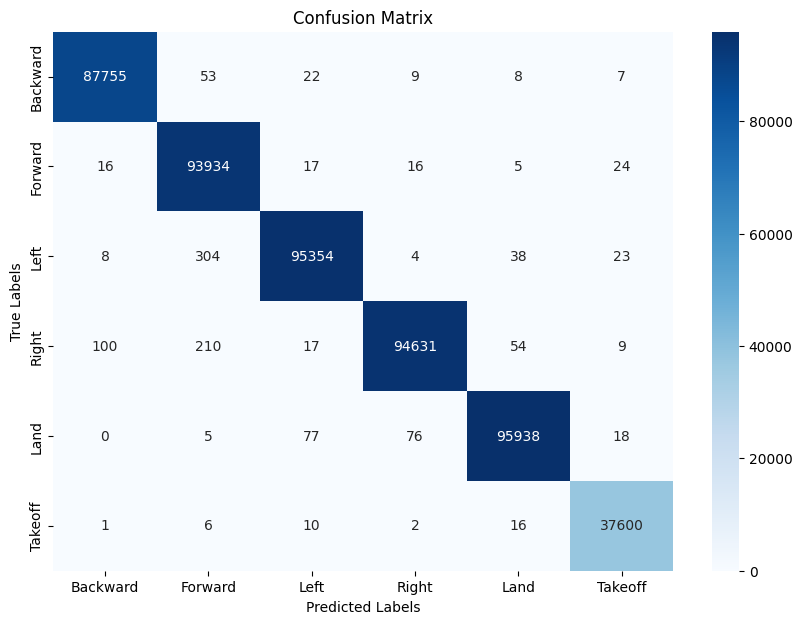

In [117]:
# create a confusion matrix with a heatmap
plt.figure(figsize=(10,7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Backward', 'Forward', 'Left', 'Right', 'Land', 'Takeoff'], yticklabels=['Backward', 'Forward', 'Left', 'Right', 'Land', 'Takeoff'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.savefig('ConfusionMatrix.png')
plt.show()

## Saving & Loading Model


### Saving
- Per pytorch documentation it is recommended to Save/Load state_dict (https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html)

In [118]:
import os

# Save in the current notebook directory
model_directory = './models/'

# Create the directory if it doesn't exist
os.makedirs(model_directory, exist_ok=True)

# Save the model
model_name = model.__class__.__name__ + ".pth"
PATH = model_directory + model_name

torch.save(model.state_dict(), PATH)
print(f"✓ Model saved to: {PATH}")

✓ Model saved to: ./models/FlexibleCNNClassifier.pth


In [119]:
print(model.__class__.__name__)

FlexibleCNNClassifier


### Loading

In [120]:
# Load the model you just saved
model_directory = './models/'
PATH = model_directory + 'FlexibleCNNClassifier.pth'

# Create a new model instance
loaded_model = FlexibleCNNClassifier(num_classes=6)

# Load the saved weights
loaded_model.load_state_dict(torch.load(PATH, weights_only=True))
loaded_model.eval()

print(f"✓ Model loaded from: {PATH}")
print(f"✓ Model is in eval mode and ready for inference")

✓ Model loaded from: ./models/FlexibleCNNClassifier.pth
✓ Model is in eval mode and ready for inference


In [123]:
# Test loading the model we just saved
print("Testing model loading...")

# Load the model you just saved (Linux path)
PATH = '/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/prediction_deep_learning/pytorch/models/FlexibleCNNClassifier.pth'

loaded_model = FlexibleCNNClassifier(num_classes=6)
loaded_model.load_state_dict(torch.load(PATH, weights_only=True))
loaded_model.eval()

print(f"✓ Model loaded from: {PATH}")

# Verify it works by making a prediction on a sample
with torch.no_grad():
    sample = X_test[:5]  # Get 5 test samples
    predictions = loaded_model(sample)
    predicted_classes = torch.argmax(predictions, dim=1)
    print(f"Sample predictions: {predicted_classes}")
    print(f"Actual labels: {y_test[:5]}")

Testing model loading...
✓ Model loaded from: /home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/prediction_deep_learning/pytorch/models/FlexibleCNNClassifier.pth
Sample predictions: tensor([4, 5, 0, 0, 3])
Actual labels: tensor([4, 5, 0, 0, 3])


## Future Considerations

- Streamline data preparation steps wherever possible
- Address failure to read one file
- Increase training & test dataset by collecting & utilizing brain signal data from more individuals
- Add early stop to model
- Train model using GPUs instead of CPU (Done 99.77% Accuracy as compared to 99.57%)
- Add more comments & references to code to further explain sections